In [2]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

import pandas as pd
import numpy as np
from matplotlib  import pyplot as plt
import seaborn as sns

2025-05-24 16:41:32.873859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [559]:
#from car_price_prossessing_functions import *
from data_preprocessing import *

In [113]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model


In [5]:
model_yaml_path = "/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/AI_Workshop/config/data_config.yaml"
cars_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/car_prices.csv'
population_file_path = '/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/states_populations_yr2015.csv'

---
---
# Imputation des valeurs manquantes avec la méthode MICE dans R

Nous allons effectuer une **imputation des valeurs manquantes** dans notre base de données à l’aide de la méthode **MICE (Multivariate Imputation by Chained Equations)**, disponible dans le logiciel **R**. Cette approche consiste à estimer des modèles de prédiction pour chaque variable contenant des données manquantes.

#### 🌱 Hypothèse de base

La méthode MICE repose sur l’hypothèse que les données sont **manquantes de façon aléatoire** (*Missing At Random*, MAR). Cela signifie que la probabilité qu’une valeur soit manquante peut dépendre des autres variables observées, mais **pas** de la valeur manquante elle-même.

#### 🔁 Principe de la méthode (exemple simplifié)

Imaginons une base avec trois variables : **A**, **B** et **C**, où seule **C** est entièrement observée.

1. **Étape initiale (itération 0)**  
   On commence par remplir les valeurs manquantes de **A** et **B** avec une valeur simple comme la moyenne, la médiane ou la valeur la plus fréquente.

2. **Étapes suivantes (itérations 1 à _maxit_)** :
   - Ajuster un modèle pour prédire **A** à partir de **B** et **C**, en utilisant les valeurs mises à jour de **B**. Utiliser ce modèle pour imputer les valeurs manquantes de **A**.
   - Ajuster ensuite un modèle pour prédire **B** à partir de **A** et **C**, en utilisant les valeurs mises à jour de **A**. Utiliser ce modèle pour imputer les valeurs manquantes de **B**.
   - Répéter ce processus plusieurs fois pour stabiliser les estimations.

Ce processus s’appelle une **imputation par équations chaînées**.

#### 📦 Imputation multiple

Pour tenir compte de l’incertitude liée aux valeurs manquantes, MICE génère plusieurs versions imputées de la base de données. Chaque version correspond à une "réalisation plausible" des données complètes.  
Dans notre cas, nous allons conserver **une seule base imputée**.

#### ⚙️ Méthodes d’imputation par défaut dans MICE

Par défaut, MICE utilise différents modèles selon le type de variable :

- **PMM** (*predictive mean matching - pmm*) pour les variables numériques
- **Régression logistique** (*logistic regression - logreg*) pour les variables binaires
- **Régression polytomique** (*polytomous regression - polyreg*) pour les variables qualitatives non ordonnées
- **Modèle à rapports proportionnels** (*proportional odds - polr*) pour les variables qualitatives ordonnées

#### 🤖 Utilisation d’une méthode de machine learning

Dans notre cas, **nous n’allons pas utiliser ces méthodes par défaut**. À la place, nous allons utiliser une approche basée sur **le machine learning** — par exemple, une **forêt aléatoire** (*random forest*) ou un **réseau de neurones profond** (*deep neural network*) — pour améliorer la qualité des imputations.


---
### Importation des données

S'assurer que l'argument $DropNa$ de la fonction $subset\_var\_of\_interest$ prenne la valeur $False$

In [6]:
config = load_config(model_yaml_path)

df = load_data(cars_file_path); pop_df = load_data(population_file_path) #.drop('population (2015)', axis=1)

df = process_dates(df)

df = define_market(
    df, market_vars=config['var_of_interest']['marketvar'], 
    market_label='market', market_code='marketid', minsize=20, DropSmallMarkets=True
)

df =  preprocess_color_interior(df)

df = subset_var_of_interest(
    df, 
    var_of_interest=config['var_of_interest']['numerical']+['state']+config['var_of_interest']['unordered'], 
    marketvar='marketid', productvar=config['var_of_interest']['productvar'][0], 
    DropNa=False
)
df = change_to_numerical(df, config['var_of_interest']['numerical'])

df = order_unorder_categorical_var(
    df, ordered=config['var_of_interest']['ordered'], unordered=config['var_of_interest']['unordered'], 
    ordered_masks=config['ordered_masks'], unordered_masks=config['unordered_masks'], 
    ordered_min_frequencies=config['ordered_min_frequencies'], 
    unordered_min_frequencies=config['unordered_min_frequencies']
)


38 rows with invalid dates have been dropped

63 markets with sizes lower than 20 have been dropped making 485 dropped rows 


Number of missing per relevant variable in the remaining dataframe 
 marketid            0
make            10282
sellingprice        0
odometer           93
condition       11794
state               0
year                0
body            13174
color           25416
interior        17808
dtype: int64


In [7]:
# Add row ids (saleid) and Remove marketid from df
if 'saleid' not in df.columns:
        df['saleid'] = df.index
df_to_impute = df.drop('marketid',axis=1)

In [8]:
# Check missing values
np.sum(df_to_impute.isna(), axis=0)

make            10282
sellingprice        0
odometer           93
condition       11794
state               0
year                0
body            13174
color           25416
interior        17808
saleid              0
dtype: int64

In [9]:
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri


def mice_impute_from_R(data, numerical=[], ordered=[], unordered=[], 
                       numerical_ordered_unordered_methods=['pmm','plor','polyreg'], nb_cores=1):

    """
    Run linear model with Lasso and cross validation using cv.glmnet from R

    numerical_ordered_unodered_lists : a list of lists of strings (column names per data type). 
    """
    
    df = data.copy()
    
    R_script = \
    \
    """
    
    library(mice)
    library(dplyr)
    library(doParallel)
    
    set.seed(10101)

    if (('saleid' %in% colnames(df))==FALSE){
      df$saleid <- seq(nrow(df))
    }

    # Set the types in data for ordered and unordered categorical columns

    if (length(ordered) > 0) {
      for (var in ordered) {
        df[,var] <- factor(df[,var], ordered = TRUE)
      }
    }
    
    if (length(unordered) > 0) {
      for (var in unordered) {
        df[,var] <- factor(df[,var], ordered = FALSE)
      }
    }

    # set the blocks and method parameters for the mice (exclude data types with no variables)
     
    blocks <- list()
    methods <- NULL
    if (length(numerical)!=0){
       methods <- c(methods, numerical_ordered_unordered_methods[1])
       blocks$numerical <- numerical
    }
    if (length(ordered)!=0){
       methods <- c(methods, numerical_ordered_unordered_methods[2])
       blocks$ordered <- ordered
    }
    if (length(unordered)!=0){
       methods <- c(methods, numerical_ordered_unordered_methods[3])
       blocks$unordered <- unordered
    }
    
    # If the dataset is too heavy, focus on incomlete rows, with eventually few additional rows
    
    incompleteness_filter <- !complete.cases(df)
    complete_df <- df[!incompleteness_filter,]
    nb_incomplete_rows <- sum(incompleteness_filter)
    if ((nb_incomplete_rows<=100000) & (nrow(df)>100000)){
      sampled_rows <- sample_n(complete_df, 100000-nb_incomplete_rows)
      sampled_rows_filter <- df$saleid %in% sampled_rows$saleid
      final_filter <- incompleteness_filter | sampled_rows_filter
    } else {
      final_filter <- incompleteness_filter
    }

    # Fit the MICE imputer
    
    imputer <- futuremice(
      data=select(df[final_filter,], -saleid),
      blocks=blocks, 
      method=methods,
      m=1, maxit=10,
      parallelseed = 10101, print = FALSE, n.core = nb_cores
    )
    
    imputed_df <- complete(imputer)
    
    imputed_df <- cbind(df[final_filter,'saleid'], imputed_df)
    colnames(imputed_df)[1] <- 'saleid'
    imputed_df <- rbind(imputed_df, df[!final_filter,])

    # Convert all factor columns back to character
    imputed_df <- imputed_df %>%
    mutate(across(where(is.factor), as.character))
    
    """
    
    pandas2ri.activate()
    robjects.globalenv['df'] = pandas2ri.py2rpy(data)
    robjects.globalenv['nb_cores'] = robjects.IntVector([nb_cores])[0]
    robjects.globalenv['numerical'] = robjects.StrVector(numerical)
    robjects.globalenv['ordered'] = robjects.StrVector(ordered)
    robjects.globalenv['unordered'] = robjects.StrVector(unordered)
    robjects.globalenv['numerical_ordered_unordered_methods'] = robjects.StrVector(numerical_ordered_unordered_methods)

    robjects.r(R_script)
    imputed_df = robjects.conversion.rpy2py(robjects.globalenv['imputed_df'])
    
    return imputed_df

In [302]:
set(imputed_values.unique())

set()

In [312]:
def plot_categorical_observed_vs_imputed(df, imputed_df, categorical, id_column='saleid', nb_subplots_rows=2, nb_subplots_cols=2):
    
    fig = plt.figure(figsize=(nb_subplots_cols*6, nb_subplots_rows*6))
    
    for i in range(len(categorical)):
        
        var = categorical[i]
        incompleteness_filter = df[var].isna()
        if np.sum(incompleteness_filter)!=0:
            incompleteness_IDs = df[incompleteness_filter][id_column]
        else:
            incompleteness_IDs = []
        observed_and_imputed_values = imputed_df[var]
        observed_values = df[var][~incompleteness_filter]
        imputed_values = imputed_df[var][imputed_df[id_column].isin(incompleteness_IDs)]
        
        # Ensure same category order
        categories = sorted(set(observed_values.unique()) | set(imputed_values.unique()) | set(observed_and_imputed_values.unique()))
        
        # Compute value frequencies, reindexed to have same order
        freq_observed_and_imputed = observed_and_imputed_values.value_counts().reindex(categories, fill_value=0)/len(observed_and_imputed_values)
        freq_observed = observed_values.value_counts().reindex(categories, fill_value=0)/len(observed_values)
        freq_imputed = imputed_values.value_counts().reindex(categories, fill_value=0)/len(imputed_values)
        
        # Plot side-by-side bars
        x = range(len(categories))
        width = 0.35
        
        ax=plt.subplot(nb_subplots_rows,nb_subplots_cols,i+1)
        plt.bar([j - 2*width/3 for j in x], freq_observed_and_imputed, width=width, color='green', label='Complete data after processing')
        plt.bar([j - width/3 for j in x], freq_observed, width=width, color='blue', alpha=0.6, label='Complete data before processing')
        if np.sum(incompleteness_filter)!=0:
            plt.bar([j + width/3 for j in x], freq_imputed, width=width, color='orange', alpha=0.3, label='Imputed missing values')
        plt.xticks(ticks=x, labels=categories)
        plt.xlabel("Category")
        plt.ylabel("Frequency")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.xticks(rotation=45)
    
    plt.show()    

In [314]:
def plot_numerical_observed_vs_imputed(df, imputed_df, numerical, id_column='saleid', nb_subplots_rows=1, nb_subplots_cols=2):
    
    fig = plt.figure(figsize=(nb_subplots_cols*6, nb_subplots_rows*6))

    for i in range(len(numerical)):
        var = numerical[i]
        
        incompleteness_filter = df[var].isna()
        if np.sum(incompleteness_filter)!=0:
            incompleteness_IDs = df[incompleteness_filter][id_column]
        else:
            incompleteness_IDs = []
        observed_and_imputed_values = imputed_df[var]
        observed_values = df[var][~incompleteness_filter]
        imputed_values = imputed_df[var][imputed_df[id_column].isin(incompleteness_IDs)]
    
        ax=plt.subplot(nb_subplots_rows,nb_subplots_cols,i+1)
        sns.histplot(observed_and_imputed_values, color='green', label='Complete data after processing', kde=True, stat='density', bins=30)
        sns.histplot(observed_values, color='blue', label='Complete data before processing', kde=True, stat='density', bins=50, alpha=0.6)
        if np.sum(incompleteness_filter)!=0:
            sns.histplot(imputed_values, color='orange', label='Imputed missing values', kde=True, stat='density', bins=50, alpha=0.3)
        plt.xticks(rotation=45)
        plt.title(var)
        plt.legend()
        plt.xlabel("Value")
        plt.ylabel("Density")
    plt.show()

---
### Imputation par MICE en utilisant les méthodes par défaut


In [17]:
imputed_df = mice_impute_from_R(
    df_to_impute,
    numerical=config['var_of_interest']['numerical'], 
    ordered=config['var_of_interest']['ordered'], 
    unordered=['state']+config['var_of_interest']['unordered'], 
    numerical_ordered_unordered_methods=['pmm','polr','polyreg'], nb_cores=5
)

R[write to console]: 
Attaching package: ‘mice’


R[write to console]: The following object is masked from ‘package:stats’:

    filter


R[write to console]: The following objects are masked from ‘package:base’:

    cbind, rbind


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: Loading required package: foreach

R[write to console]: Loading required package: iterators

R[write to console]: Loading required package: parallel

R[write to console]: 
Attaching package: ‘purrr’


R[write to console]: The following objects are masked from ‘package:foreach’:

    accumulate, when


R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In check.cores(n.core, available, m) :
R[write to console]: 
 
R[write to console]: 

In [18]:
# Check missing values
np.sum(imputed_df.isna(), axis=0)

saleid          0
make            0
sellingprice    0
odometer        0
condition       0
state           0
year            0
body            0
color           0
interior        0
dtype: int64

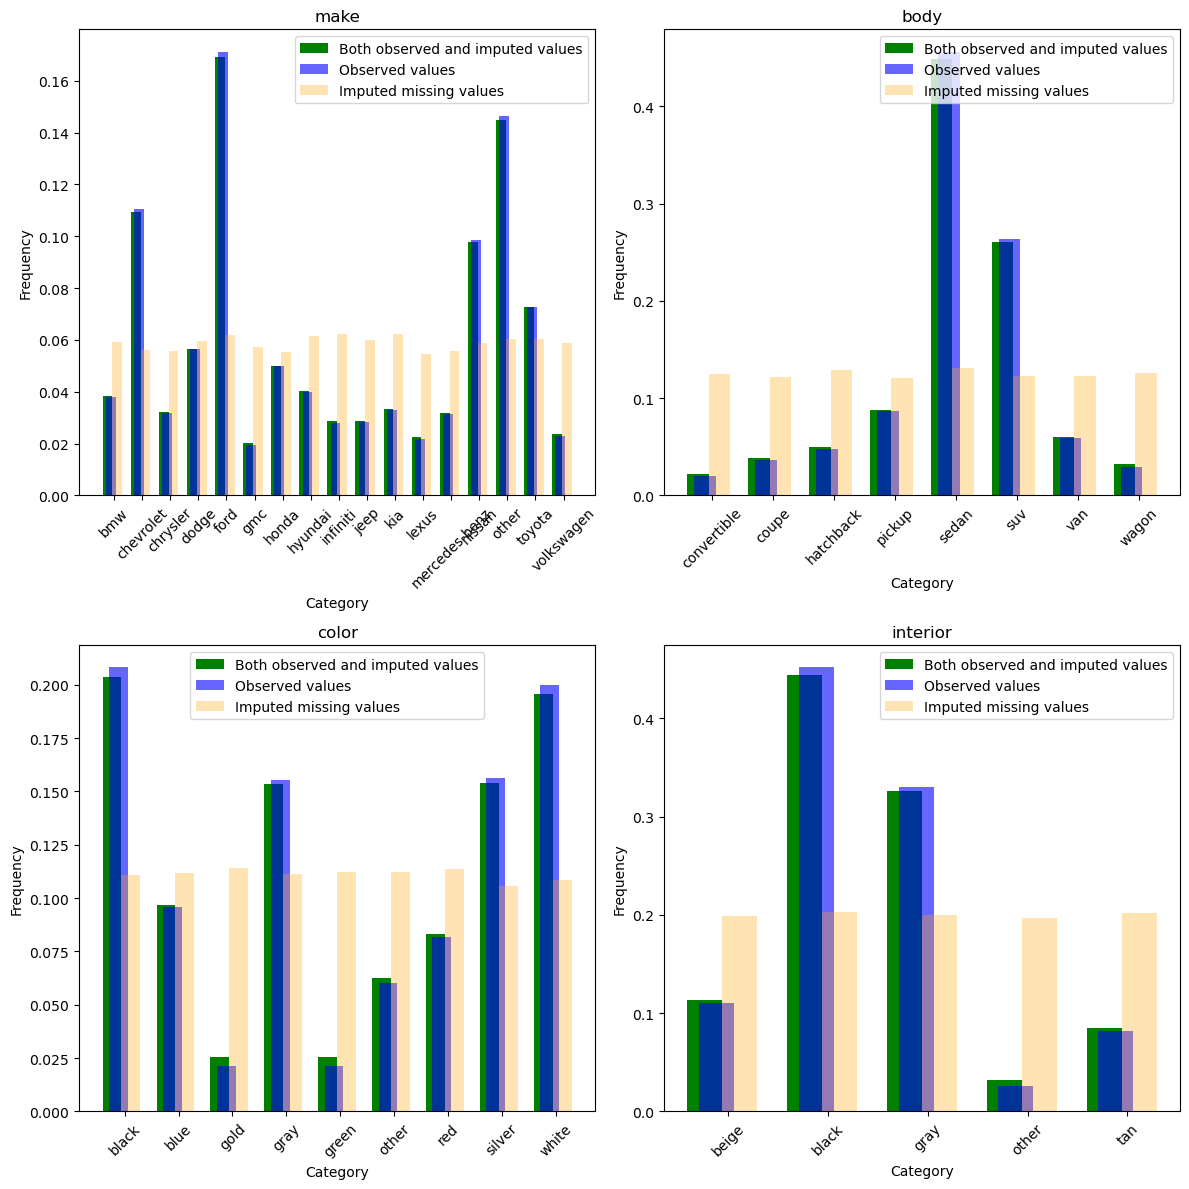

In [19]:

plot_categorical_observed_vs_imputed(
    df_to_impute, imputed_df, categorical=['make','body','color','interior'], id_column='saleid', nb_subplots_rows=2, nb_subplots_cols=2
)


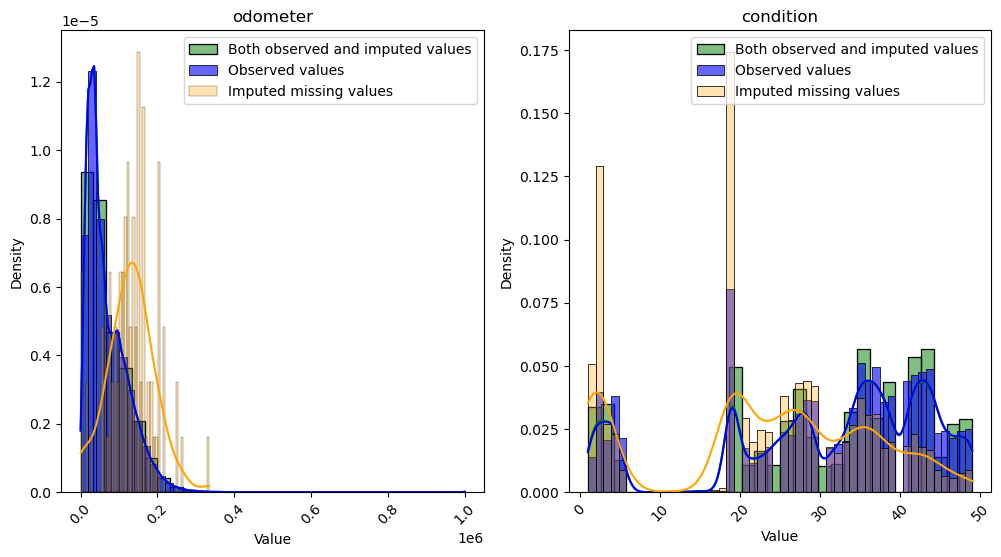

In [20]:
plot_numerical_observed_vs_imputed(
    df_to_impute, imputed_df, numerical=['odometer','condition'], id_column='saleid', nb_subplots_rows=1, nb_subplots_cols=2
)

---
### Imputation par MICE en utilisant les méthodes des forêts aléatoires


In [22]:
imputed_df = mice_impute_from_R(
    df_to_impute,
    numerical=config['var_of_interest']['numerical'], 
    ordered=config['var_of_interest']['ordered'], 
    unordered=['state']+config['var_of_interest']['unordered'], 
    numerical_ordered_unordered_methods=['rf','rf','rf'], nb_cores=5
)

# If we want to customize the random forest parameters inside the MICE procedure, and if we want to get the prediction performances, 
# we can define:
"""
mice.impute.rf_custom <- function(y, ry, x, wy = NULL, ...) {
  require(randomForest)
  rf <- randomForest(x[ry, ], y[ry], ntree = 500, mtry = 4)  # ← your custom settings
  preds <- predict(rf, newdata = x[!ry, ])

  # Evaluate performance (on training set or via OOB)
  y_train <- y[ry]
  y_pred_train <- predict(rf, newdata = x[ry, ])
  mse <- mean((y_pred_train - y_train)^2)
  cat("RF training MSE:", round(mse, 3), "\n")

  return(preds)
}

then set method = "rf_custom" for the columns to be imputed using random forests.
"""

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In check.cores(n.core, available, m) :
R[write to console]: 
 
R[write to console]:  'n.core' exceeds the maximum number of available cores on your machine or the number of imputations, and is set to 1



'\nmice.impute.rf_custom <- function(y, ry, x, wy = NULL, ...) {\n  require(randomForest)\n  rf <- randomForest(x[ry, ], y[ry], ntree = 500, mtry = 4)  # ← your custom settings\n  preds <- predict(rf, newdata = x[!ry, ])\n\n  # Evaluate performance (on training set or via OOB)\n  y_train <- y[ry]\n  y_pred_train <- predict(rf, newdata = x[ry, ])\n  mse <- mean((y_pred_train - y_train)^2)\n  cat("RF training MSE:", round(mse, 3), "\n")\n\n  return(preds)\n}\n\nthen set method = "rf_custom" for the columns to be imputed using random forests.\n'

In [23]:
# Check missing values
np.sum(imputed_df.isna(), axis=0)

saleid          0
make            0
sellingprice    0
odometer        0
condition       0
state           0
year            0
body            0
color           0
interior        0
dtype: int64

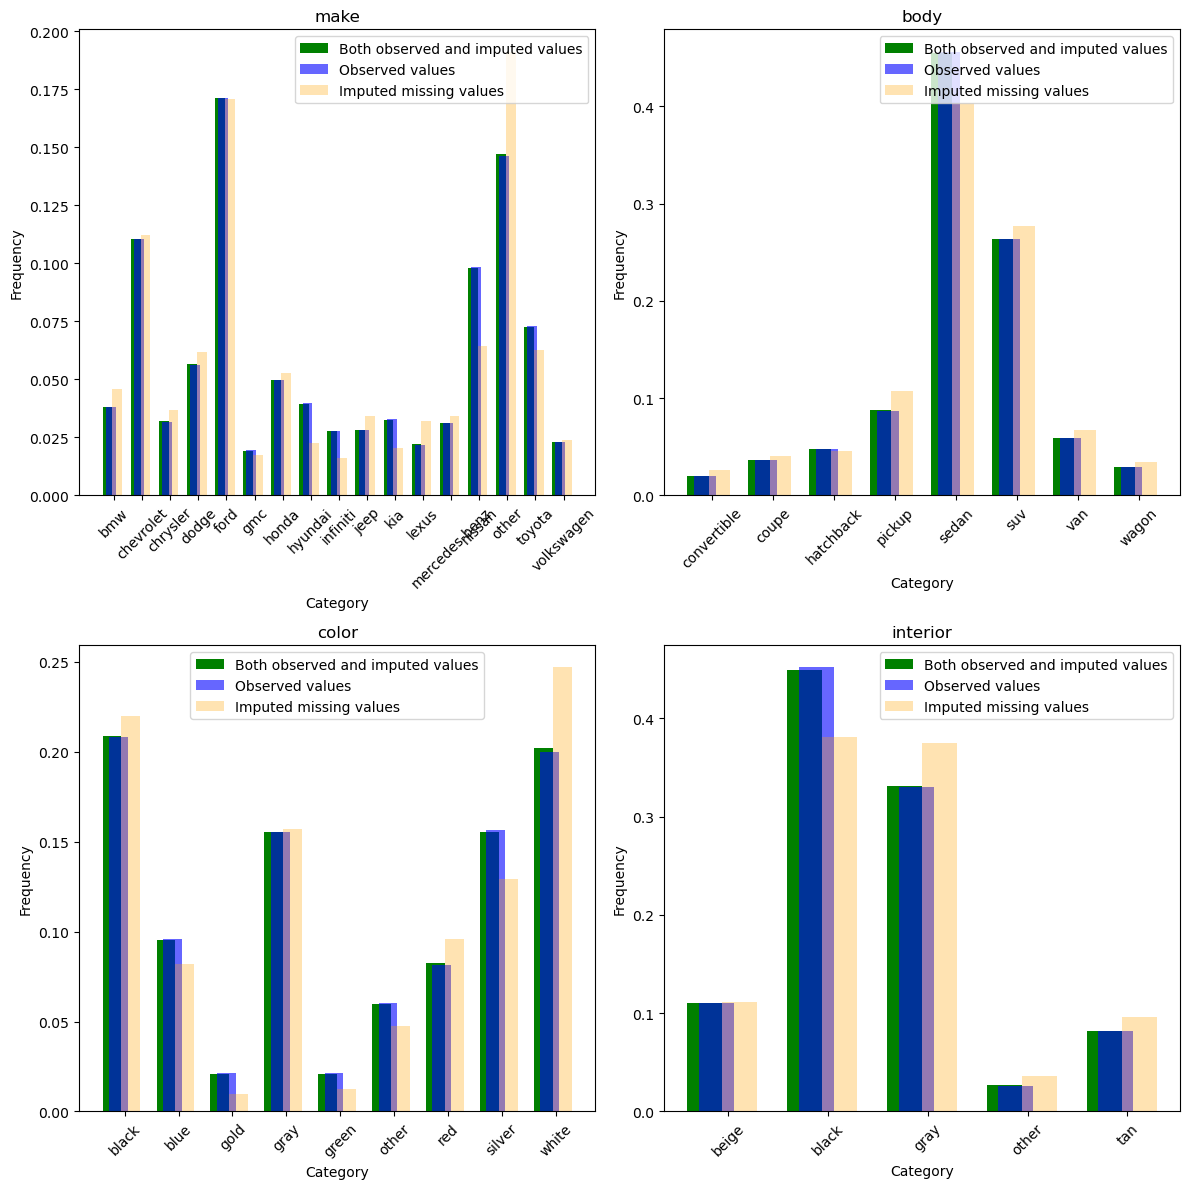

In [24]:
plot_categorical_observed_vs_imputed(
    df_to_impute, imputed_df, categorical=['make','body','color','interior'], id_column='saleid', nb_subplots_rows=2, nb_subplots_cols=2
)

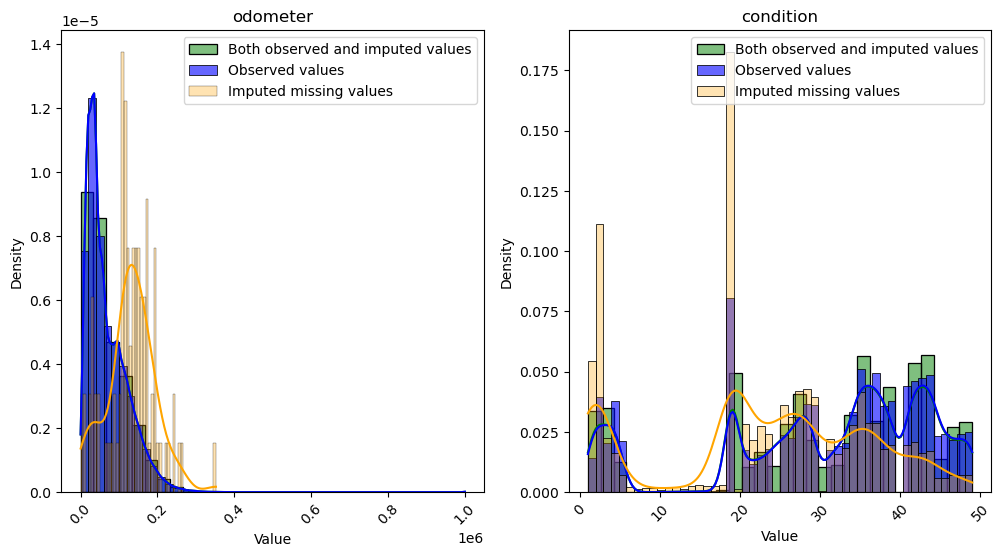

In [25]:
plot_numerical_observed_vs_imputed(
    df_to_impute, imputed_df, numerical=['odometer','condition'], id_column='saleid', nb_subplots_rows=1, nb_subplots_cols=2
)

---
---
# Détection et remplacement des valeurs aberrantes par AutoEncodeur (une application du deep learning)

Dans l’analyse de données économiques ou financières, la présence de valeurs aberrantes (outliers) peut biaiser les résultats économétriques, fausser les estimateurs et réduire la robustesse des modèles.

Les AutoEncodeurs, issus du deep learning, offrent une méthode innovante pour identifier automatiquement ces anomalies. Il s’agit de réseaux de neurones entraînés à reconstruire les données “normales” en apprenant leur structure latente. Lorsqu’une observation ne peut pas être bien reconstruite (c’est-à-dire que l’erreur de reconstruction est élevée), cela signale une valeur atypique.

Cette méthode permet non seulement de détecter les outliers, mais aussi de les remplacer par des valeurs reconstruites par le modèle, souvent plus cohérentes avec la structure globale des données. Cela améliore la qualité des jeux de données utilisés dans les analyses économétriques et les modèles prédictifs.

In [608]:
def reverse_tranform_data(arr, df, df_type='numerical', df_scaler=None):
    """
    reverse standardizing for numerical variables
    reverse encoding for categorical columns
    """

    if df_type=='numerical':
        original_df = df_scaler.inverse_transform(arr)
        original_df = pd.DataFrame(original_df, columns=df.columns, index=df.index)
    if df_type =='categorical':
        original_df = pd.DataFrame(arr, columns=df.columns, index=df.index)
        colname = str(original_df.columns[0]).rpartition('_')[0]
        original_df = original_df.idxmax(axis=1).astype('string').str.rsplit('_', n=1).str[-1]
        original_df = pd.Series(original_df, name=colname)
        
    return original_df

def transform_data(df, df_type='numerical', train=True, df_scaler=None):
    
    if df_type=='numerical':
        if train:
            df_scaler = StandardScaler().fit(df)
            #df_scaler = MinMaxScaler().fit(df)
        transformed_df = pd.DataFrame(df_scaler.transform(df), index=df.index, columns=df.columns)  
        results = transformed_df, df_scaler
    if df_type == 'categorical':
        transformed_df = pd.get_dummies(df)
        results = transformed_df, None

    return results

In [610]:
# Set the data to use for imputation
df_for_anomalies = imputed_df.drop('saleid',axis=1)
# count levels for the categorical columns
for var in ['state','year','make','body','color','interior']:
    print(f"Column {var} has {len(imputed_df[var].unique())} levels")

Column state has 38 levels
Column year has 17 levels
Column make has 17 levels
Column body has 8 levels
Column color has 9 levels
Column interior has 5 levels


In [612]:

df_train, df_test = train_test_split(df_for_anomalies, test_size=0.1, random_state=42)

X_train = dict()
X_test  = dict()
X_train_transformed = dict()
X_test_transformed = dict()
X_numeric_scalers = dict()
types = dict()

for var in config['var_of_interest']['numerical']:
    X_train[var] = df_train[[var]].copy()
    X_test[var] = df_test[[var]].copy()
    X_train_transformed[var], X_numeric_scalers[var] = transform_data(
        X_train[var], df_type='numerical', train=True, df_scaler=None
    )
    X_test_transformed[var], _ = transform_data(
        X_test[var], df_type='numerical', train=False, df_scaler=X_numeric_scalers[var]
    )
    types[var] = 'numerical'

for var in ['state']+config['var_of_interest']['categorical']:
    X_train[var] = df_train[[var]].copy()
    X_test[var] = df_test[[var]].copy()
    X_train_transformed[var], _ = transform_data(X_train[var], df_type='categorical')
    X_test_transformed[var], _ = transform_data(X_test[var], df_type='categorical')
    types[var] = 'categorical'
    

In [616]:
def auto_encoder(X, types, encoder_shapes=[50,10], loss={'numerical':'mse', 'categorical':'cce'},
                 metrics={'numerical':['mae'], 'categorical':['accuracy']}, numerical_loss_weight = 1.0):

    # Input:
    input_dim = np.sum([X[var].shape[1] for var in X.keys()])
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoder = Dense(encoder_shapes[0], activation='relu')(input_layer)
    for t in range(1,len(encoder_shapes)):
        encoder = Dense(encoder_shapes[t], activation='relu')(encoder)

    # Decoder
    decoder_shapes = list(reversed(encoder_shapes))
    decoder = Dense(decoder_shapes[0], activation='relu')(encoder)
    for t in range(1,len(decoder_shapes)):
        decoder = Dense(decoder_shapes[t], activation='relu')(decoder)

    # Multi-outputs
    output = dict()
    loss_functions = dict()
    metric_functions = dict()
    loss_weights = dict()
    for var in X.keys():
        if types[var] == 'numerical':
            activation = 'linear'
            loss_functions[var] = loss['numerical']
            metric_functions[var] = metrics['numerical']
            loss_weights[var] = numerical_loss_weight
        if types[var] == 'categorical':
            activation = 'softmax'
            loss_functions[var] = loss['categorical']
            metric_functions[var] = metrics['categorical']
            loss_weights[var] = 1.0
        output[var] = Dense(X[var].shape[1], activation=activation, name=var)(decoder)

    print(f"\nloss_functions:\n{loss_functions}\n\nloss_weights:\n{loss_weights}\n\nmetrics:\n{metrics}\n\n")
    
    # Model with multiple outputs
    autoencoder = Model(inputs=input_layer, outputs = output)

    # Compile model and print summary  
    autoencoder.compile(optimizer='adam', loss=loss_functions, loss_weights=loss_weights, metrics=metric_functions)
    autoencoder.summary()
    
    history = autoencoder.fit(
        pd.concat(X.values(), axis=1).astype('float'), X, 
        epochs=100, batch_size=1000, validation_split=0.2, verbose=False
    )

    return autoencoder, history

In [618]:
encoder_shapes=[50,10] 
loss={'numerical':'mae', 'categorical':'categorical_crossentropy'}
metrics={'numerical':['mae'], 'categorical':['accuracy']} 
numerical_loss_weight = 10.0

In [620]:
autoencoder, history = auto_encoder(
    X_train_transformed, types=types, encoder_shapes=encoder_shapes, 
    loss=loss, metrics=metrics, numerical_loss_weight = numerical_loss_weight
)


loss_functions:
{'sellingprice': 'mae', 'odometer': 'mae', 'condition': 'mae', 'state': 'categorical_crossentropy', 'year': 'categorical_crossentropy', 'make': 'categorical_crossentropy', 'body': 'categorical_crossentropy', 'color': 'categorical_crossentropy', 'interior': 'categorical_crossentropy'}

loss_weights:
{'sellingprice': 10.0, 'odometer': 10.0, 'condition': 10.0, 'state': 1.0, 'year': 1.0, 'make': 1.0, 'body': 1.0, 'color': 1.0, 'interior': 1.0}

metrics:
{'numerical': ['mae'], 'categorical': ['accuracy']}




Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 97)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_110 (Dense)   │ (None, 50)        │      4,900 │ input_layer_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_111 (Dense)   │ (None, 10)        │        510 │ dense_110[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_112 (Dense)   │ (None, 10)        │        110 │ dense_111[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_113 (Dense)   │ (None, 50)        │        550 │ dense_112[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ body (Dense)        │ (None, 8)         │        408 │ dense_113[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color (Dense)       │ (None, 9)         │        459 │ dense_113[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ condition (Dense)   │ (None, 1)         │         51 │ dense_113[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interior (Dense)    │ (None, 5)         │        255 │ dense_113[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ make (Dense)        │ (None, 17)        │        867 │ dense_113[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ odometer (Dense)    │ (None, 1)         │         51 │ dense_113[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sellingprice        │ (None, 1)         │         51 │ dense_113[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state (Dense)       │ (None, 38)        │      1,938 │ dense_113[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year (Dense)        │ (None, 17)        │        867 │ dense_113[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,017 (43.04 KB)

 Trainable params: 11,017 (43.04 KB)

 Non-trainable params: 0 (0.00 B)

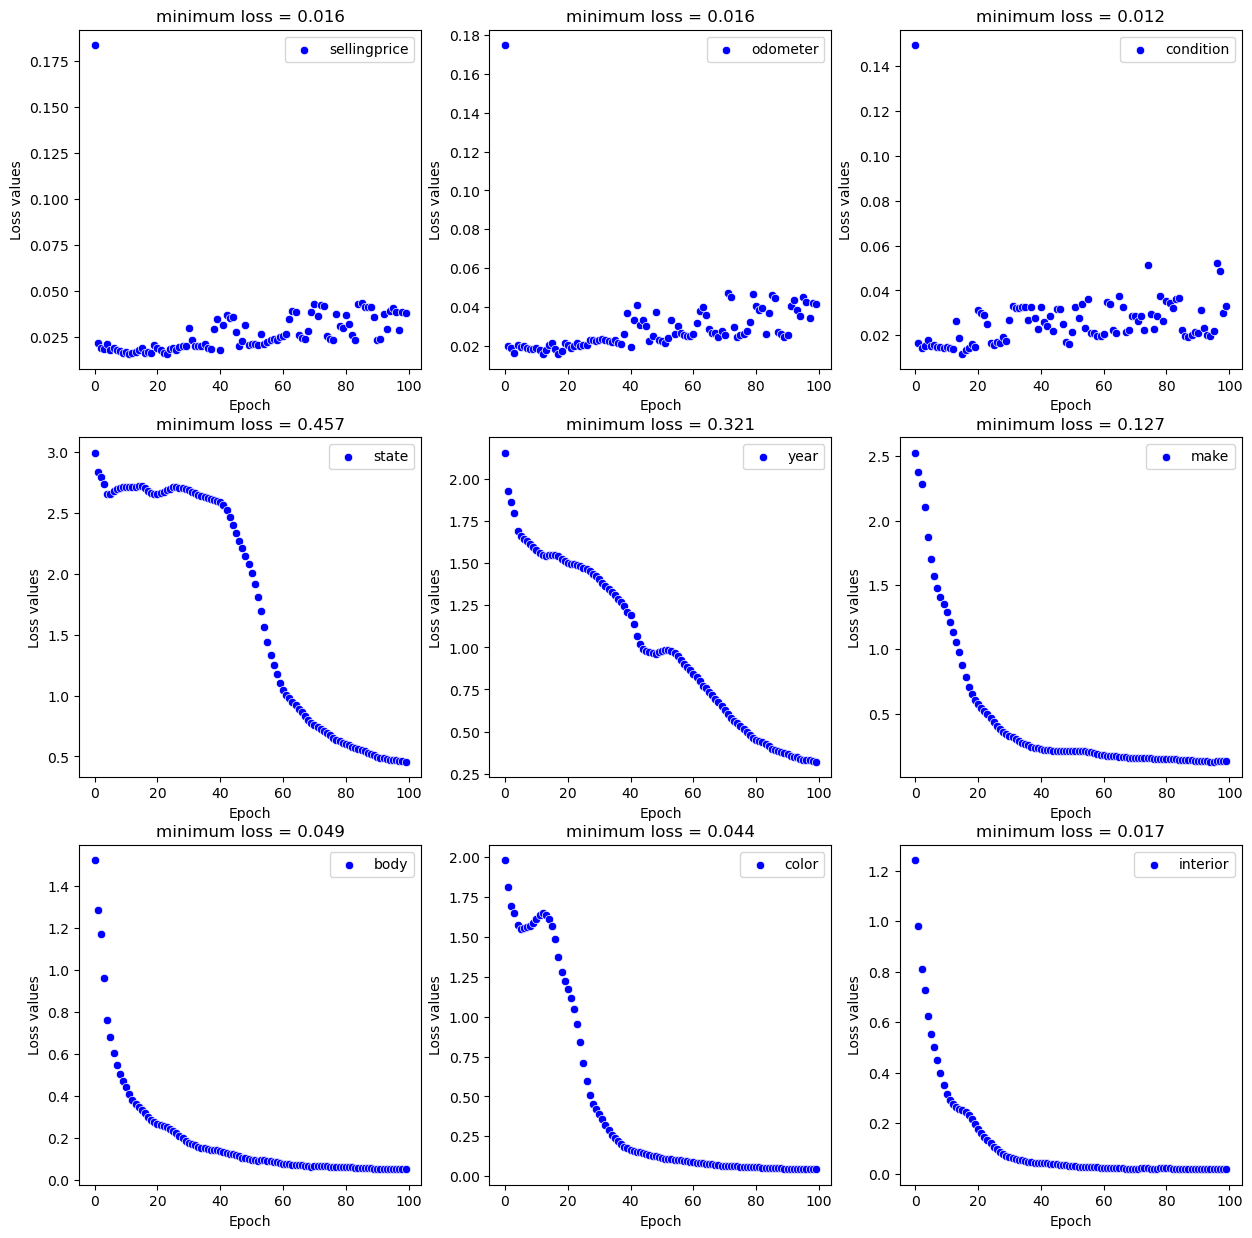

In [621]:
# Plot loss values across epochs 

fig = plt.figure(figsize=(15,15))

for i in range(len(X_train.keys())):
    var = list(X_train.keys())[i]
    ax = plt.subplot(3,3,i+1)
    sns.scatterplot(history.history[f"{var}_loss"], color='blue', label=var)
    plt.xlabel('Epoch'); plt.ylabel('Loss values')
    plt.title("minimum loss = " + str(round(np.min(history.history[f"{var}_loss"]), 3)))


In [622]:
# Get predictions of transformed data

X_train_transformed_pred = autoencoder.predict(pd.concat(X_train_transformed.values(), axis=1).astype('float'))

X_test_transformed_pred = autoencoder.predict(pd.concat(X_test_transformed.values(), axis=1).astype('float'))


15703/15703 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [623]:

# Reverse-transform the predictions

X_train_pred = dict()
X_test_pred = dict()

for var in X_train.keys():
    
    if types[var] == 'numerical':
        X_train_pred[var] = reverse_tranform_data(
            X_train_transformed_pred[var], X_train_transformed[var], df_type='numerical', df_scaler=X_numeric_scalers[var]
        )
        X_test_pred[var] = reverse_tranform_data(
            X_test_transformed_pred[var], X_test_transformed[var], df_type='numerical', df_scaler=X_numeric_scalers[var]
        )
    if types[var] == 'categorical':
        X_train_pred[var] = reverse_tranform_data(
            X_train_transformed_pred[var], X_train_transformed[var], df_type='categorical'
        )       
        X_test_pred[var] = reverse_tranform_data(
            X_test_transformed_pred[var], X_test_transformed[var], df_type='categorical'
        ) 
    
# Merge the predicted data

df_train_pred = pd.concat(X_train_pred.values(), axis=1)[df_train.columns]
df_train_pred['id'] = df_train_pred.index

df_test_pred = pd.concat(X_test_pred.values(), axis=1)[df_test.columns]
df_test_pred['id'] = df_test_pred.index

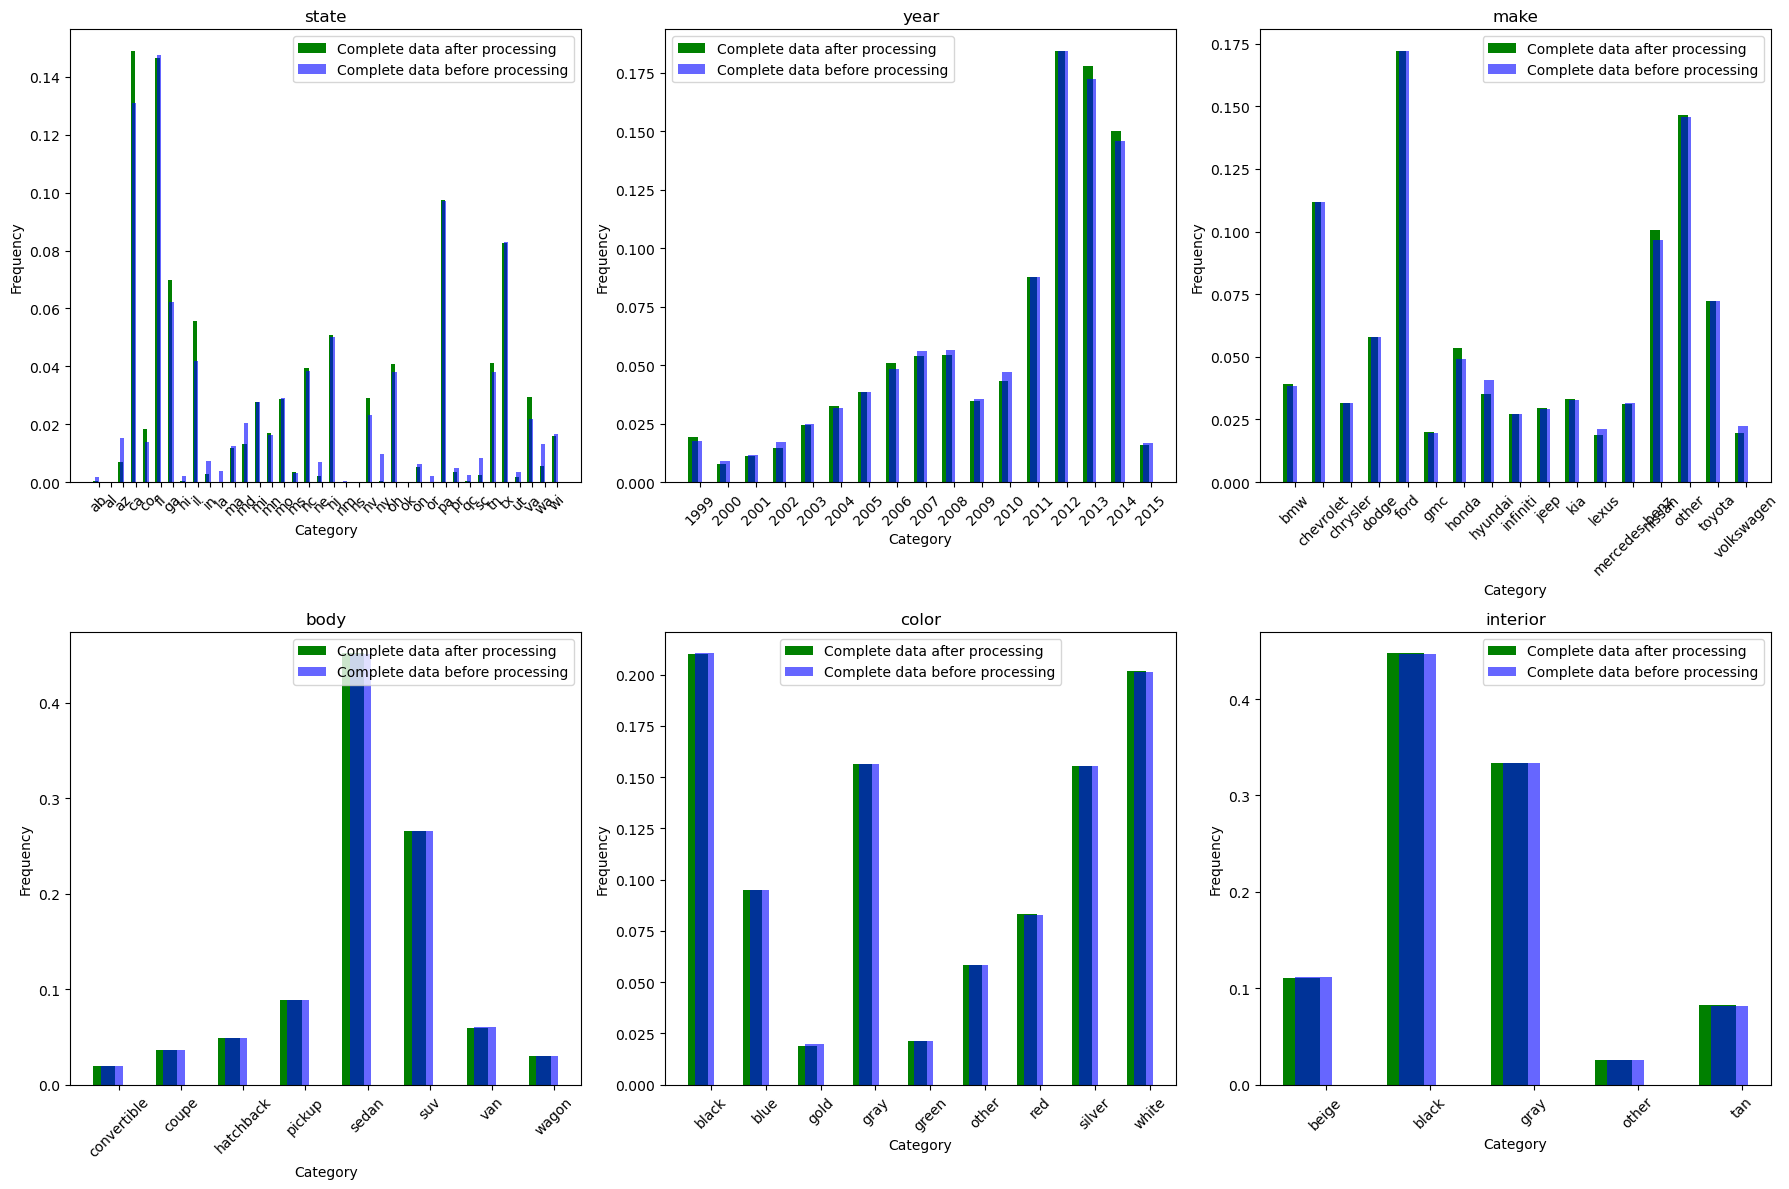

In [624]:
# Plot the distribution of the original vs predicted data  (i.e. noisy vs denoised data) with test sample

plot_categorical_observed_vs_imputed(
    df_test, df_test_pred, categorical=['state','year','make','body','color','interior'], 
    id_column='id', nb_subplots_rows=2, nb_subplots_cols=3
)


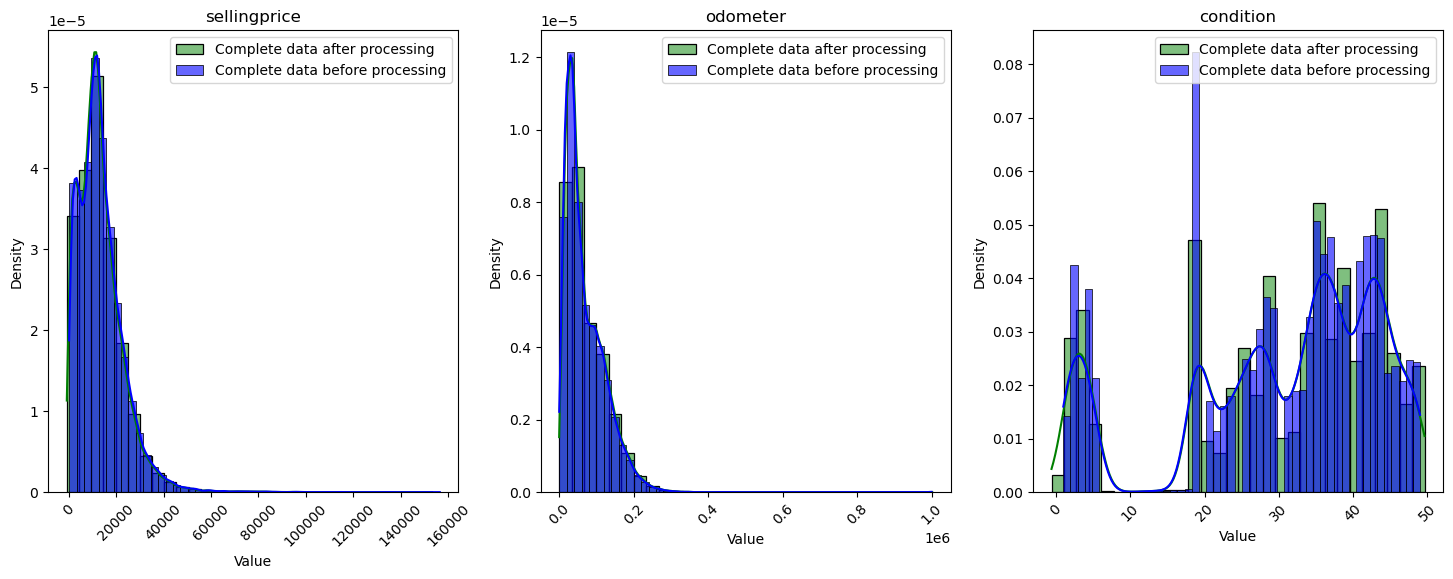

In [625]:
# Plot the distribution of the original vs predicted data  (i.e. noisy vs denoised data) with test sample

plot_numerical_observed_vs_imputed(
    df_test, df_test_pred, numerical=['sellingprice','odometer','condition'], id_column='id', nb_subplots_rows=1, nb_subplots_cols=3
)


In [626]:
from tensorflow.keras.losses import get as get_loss

def predict_losses(X, X_pred, loss={'numerical':'mse', 'categorical':'categorical_crossentropy'}, loss_weights=1.0):

    """
    X, X_pred: both dictionaries of dataframes
    """

    loss_weights = dict(zip(
        X.keys(), 
        [numerical_loss_weight if types[var]=='numerical' else 1.0 for var in X.keys()]
    ))
    losses = dict()
    total_loss = 0
    for var in X.keys():
        losses[var] = get_loss(loss[types[var]])(X[var], X_pred[var])
        total_loss = total_loss + loss_weights[var]*losses[var]
    
    losses_df = pd.DataFrame(np.vstack(list(losses.values())).T, index=list(X.values())[0].index, columns=X.keys())
    
    losses_df['total_loss'] = total_loss

    return losses_df

In [627]:

train_losses_df = predict_losses(
    X_train_transformed, X_train_transformed_pred, 
    loss={'numerical':'mse', 'categorical':'categorical_crossentropy'}, loss_weights=1.0
)

test_losses_df = predict_losses(
    X_test_transformed, X_test_transformed_pred, 
    loss={'numerical':'mse', 'categorical':'categorical_crossentropy'}, loss_weights=1.0
)

In [628]:
train_losses_df['total_loss'].describe(percentiles=np.arange(200)/200)

count    502482.000000
mean          1.063375
std           1.236062
min           0.030639
0%            0.030639
             ...      
98%           4.280924
98.5%         4.708504
99%           5.418901
99.5%         6.955228
max          78.028831
Name: total_loss, Length: 205, dtype: float64

In [637]:
# High-level anomalies 
display(df_test[test_losses_df['total_loss'] >= 30])

,make,sellingprice,odometer,condition,state,year,body,color,interior
454114,other,153250.0,2343.0,5.0,pa,2014,sedan,gray,gray
451999,ford,750.0,999999.0,19.0,ms,2007,sedan,white,tan
275,hyundai,2500.0,999999.0,1.0,ca,2013,sedan,blue,gray
440660,mercedes-benz,156500.0,15019.0,43.0,fl,2013,coupe,gray,tan
410287,other,130500.0,13840.0,35.0,ga,2013,convertible,gray,tan
385721,kia,3100.0,999999.0,1.0,tx,2014,sedan,black,black


In [639]:
# Denoised values of High-level anomalies 
display(df_test_pred[test_losses_df['total_loss'] >= 30])

,make,sellingprice,odometer,condition,state,year,body,color,interior,id
454114,lexus,151484.968750,3.106257e+03,6.150803,ga,2012,sedan,silver,black,454114
451999,ford,2358.453369,9.582024e+05,12.271149,ca,2003,sedan,gold,gray,451999
275,gmc,3388.303955,1.001530e+06,2.608255,on,2003,sedan,silver,gray,275
440660,mercedes-benz,153282.968750,1.211561e+04,41.539707,nj,2011,suv,gray,other,440660
410287,lexus,128749.281250,1.129836e+04,36.277660,nv,2014,convertible,silver,other,410287
385721,honda,2744.775635,9.987539e+05,0.692221,nc,2005,sedan,black,black,385721
